# Life Expectancy Regression using MLP
This notebook develops a Multi-Layer Perceptron (MLP) model utilizing Scikit-learn to predict life expectancy based on variables provided by the World Health Organization (WHO) dataset.

## 1. Data Loading & Parsing
Loading the raw CSV file, encoding categorical variables, and isolating features from the target variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load dataset
raw_data = pd.read_csv('Life Expectancy Data.csv')

# Handle Categorical features
if 'Status' in raw_data.columns:
    raw_data['Status'] = raw_data['Status'].replace({'Developing': 0, 'Developed': 1})
    
if 'Country' in raw_data.columns:
    raw_data.drop(columns=['Country'], inplace=True)

y_label = [col for col in raw_data.columns if 'Life expectancy' in col][0]
raw_data.dropna(subset=[y_label], inplace=True)

features = raw_data.drop(columns=[y_label])
target = raw_data[y_label]

## 2. Preprocessing: Outliers & Missing Values
Applying IQR clipping to handle statistical outliers across all feature spaces and filling remaining missing parameters via column medians.

In [2]:
def apply_iqr_clipping(column_data):
    q_low = column_data.quantile(0.25)
    q_high = column_data.quantile(0.75)
    iqr_value = q_high - q_low
    
    limit_lower = q_low - 1.5 * iqr_value
    limit_upper = q_high + 1.5 * iqr_value
    return np.clip(column_data, limit_lower, limit_upper)

for feat in features.columns:
    features[feat] = apply_iqr_clipping(features[feat])

features.fillna(features.median(), inplace=True)

,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,0,263.0,55,0.01,71.279624,65.0,905.625,19.1,70,49.5,8.16,65.0,0.10,584.259210,1.827185e+07,15.6,15.6375,0.479,10.1
1,2014,0,271.0,55,0.01,73.523582,62.0,492.000,18.6,70,58.0,8.18,62.0,0.10,612.696514,3.275820e+05,15.6,15.6375,0.476,10.0
2,2013,0,268.0,55,0.01,73.219243,64.0,430.000,18.1,70,62.0,8.13,64.0,0.10,631.744976,1.827185e+07,15.6,15.6375,0.470,9.9
3,2012,0,272.0,55,0.01,78.184215,67.0,905.625,17.6,70,67.0,8.52,67.0,0.10,669.959000,3.696958e+06,15.6,15.6375,0.463,9.8
4,2011,0,275.0,55,0.01,7.097109,68.0,905.625,17.2,70,68.0,7.87,68.0,0.10,63.537231,2.978599e+06,15.6,15.6375,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,2004,0,459.0,27,4.36,0.000000,68.0,31.000,27.1,42,67.0,7.13,65.0,1.85,454.366654,1.277751e+07,9.4,9.4000,0.407,9.2
2934,2003,0,459.0,26,4.06,0.000000,47.0,905.625,26.7,41,49.5,6.52,68.0,1.85,453.351155,1.263390e+07,9.8,9.9000,0.418,9.5
2935,2002,0,73.0,25,4.43,0.000000,73.0,304.000,26.3,40,73.0,6.53,71.0,1.85,57.348340,1.255250e+05,1.2,1.3000,0.427,10.0
2936,2001,0,459.0,25,1.72,0.000000,76.0,529.000,25.9,39,76.0,6.16,75.0,1.85,548.587312,1.236616e+07,1.6,1.7000,0.427,9.8


## 3. Data Splitting & Z-Score Standardization
Splitting data into standard 70% Train, 15% Validation, and 15% Test partitions, followed by proper Z-score standardization to avoid data leakage.

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(features, target, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42)

scaler_obj = StandardScaler()
X_tr_scaled = scaler_obj.fit_transform(X_train)
X_val_scaled = scaler_obj.transform(X_val)
X_test_scaled = scaler_obj.transform(X_test)

print(f"Total valid records: {len(raw_data)}")
print(f"Training shape:      {X_tr_scaled.shape}")
print(f"Validation shape:    {X_val_scaled.shape}")
print(f"Testing shape:       {X_test_scaled.shape}\n")

Total valid records: 2928
Training shape:      (2048, 20)
Validation shape:    (440, 20)
Testing shape:       (440, 20)



## 4. Custom Training Helper Functions
Functions to compute total trainable network weights/biases and record historical losses epoch-by-epoch using the warm_start mechanism.

In [4]:
def get_trainable_params(nn_model):
    total = 0
    for weight, bias in zip(nn_model.coefs_, nn_model.intercepts_):
        total += (weight.shape[0] * weight.shape[1]) + bias.shape[0]
    return total

def fit_mlp_custom_epochs(layer_architecture, max_epochs=150):
    regressor = MLPRegressor(
        hidden_layer_sizes=layer_architecture, 
        activation='relu', 
        solver='adam', 
        max_iter=1,          
        warm_start=True,     
        random_state=42
    )
    
    err_train, err_val = [], []
    for _ in range(max_epochs):
        regressor.fit(X_tr_scaled, y_train)
        preds_tr = regressor.predict(X_tr_scaled)
        preds_val = regressor.predict(X_val_scaled)
        
        err_train.append(mean_squared_error(y_train, preds_tr))
        err_val.append(mean_squared_error(y_val, preds_val))
        
    return regressor, err_train, err_val

## 5. Model Training (Networks A, B, and C)
Executing full training loops for single-layer, two-layer, and a deep architectural network variant.

In [5]:
TOTAL_EPOCHS = 150

# Architecture A
print(">>> Training Network A (1x16) ...")
net_A, tr_loss_A, va_loss_A = fit_mlp_custom_epochs((16,), TOTAL_EPOCHS)
print(f"    Params in Network A: {get_trainable_params(net_A)}")

# Architecture B
print("\n>>> Training Network B (16, 8) ...")
net_B, tr_loss_B, va_loss_B = fit_mlp_custom_epochs((16, 8), TOTAL_EPOCHS)
print(f"    Params in Network B: {get_trainable_params(net_B)}")

# Architecture C (Deeper)
print("\n>>> Training Network C (64, 32, 16) ...")
net_C, tr_loss_C, va_loss_C = fit_mlp_custom_epochs((64, 32, 16), TOTAL_EPOCHS)
print(f"    Params in Network C: {get_trainable_params(net_C)}")

>>> Training Network A (1x16) ...
    Params in Network A: 353

>>> Training Network B (16, 8) ...
    Params in Network B: 481

>>> Training Network C (64, 32, 16) ...
    Params in Network C: 3969


## 6. Performance Evaluation & Visualization
Calculating final regression metrics (MSE, RMSE, R²) against unseen test distributions and visualizing convergence plots.


--- Network A (16) Final Test Metrics ---
 * MSE:  216.7237
 * RMSE: 14.7215
 * R²:   -1.6268

--- Network B (16, 8) Final Test Metrics ---
 * MSE:  18.2061
 * RMSE: 4.2669
 * R²:   0.7793

--- Network C (64, 32, 16) Final Test Metrics ---
 * MSE:  9.3836
 * RMSE: 3.0633
 * R²:   0.8863


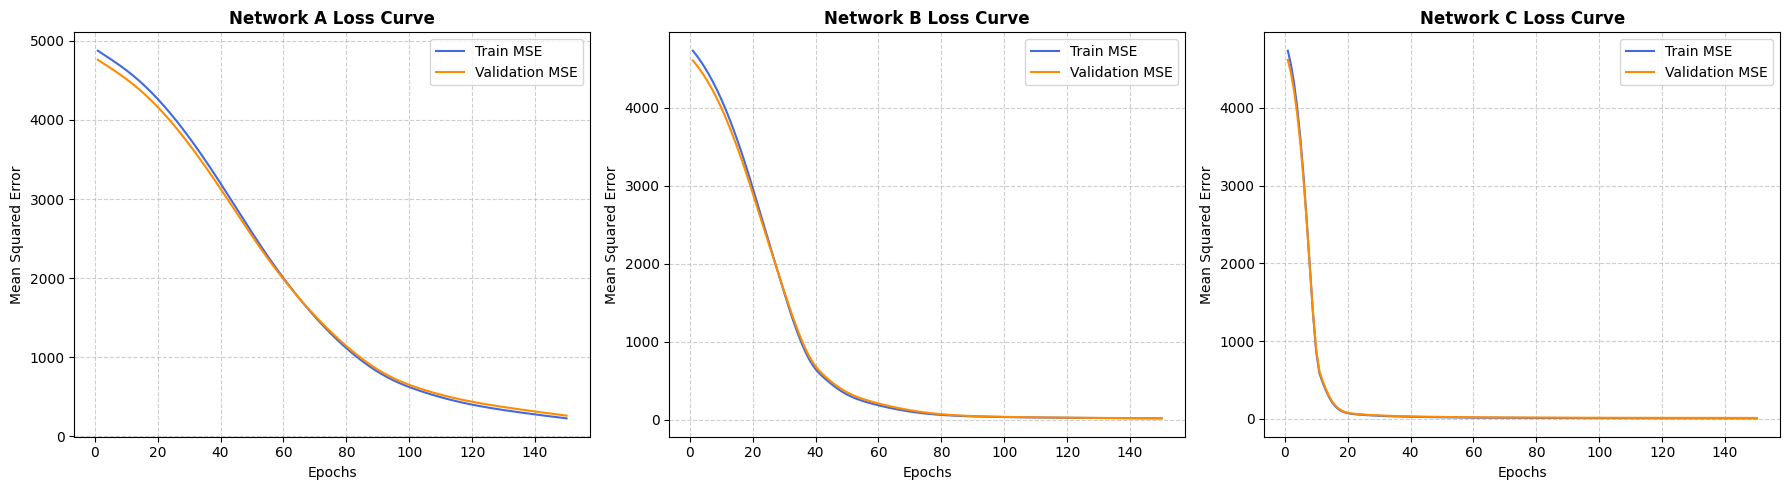

In [6]:
def assess_test_performance(nn_model, alias):
    test_preds = nn_model.predict(X_test_scaled)
    mse_val = mean_squared_error(y_test, test_preds)
    rmse_val = np.sqrt(mse_val)
    r2_val = r2_score(y_test, test_preds)
    
    print(f"\n--- {alias} Final Test Metrics ---")
    print(f" * MSE:  {mse_val:.4f}")
    print(f" * RMSE: {rmse_val:.4f}")
    print(f" * R²:   {r2_val:.4f}")

# Assess performance
assess_test_performance(net_A, "Network A (16)")
assess_test_performance(net_B, "Network B (16, 8)")
assess_test_performance(net_C, "Network C (64, 32, 16)")

# Side-by-side plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epoch_range = range(1, TOTAL_EPOCHS + 1)

def plot_learning_curve(ax, train_loss, val_loss, title):
    ax.plot(epoch_range, train_loss, label='Train MSE', color='royalblue', lw=1.5)
    ax.plot(epoch_range, val_loss, label='Validation MSE', color='darkorange', lw=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Mean Squared Error')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plot_learning_curve(axes[0], tr_loss_A, va_loss_A, 'Network A Loss Curve')
plot_learning_curve(axes[1], tr_loss_B, va_loss_B, 'Network B Loss Curve')
plot_learning_curve(axes[2], tr_loss_C, va_loss_C, 'Network C Loss Curve')

plt.tight_layout()
plt.show()